In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

2023-07-15 00:44:49.504238: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/intel/inteloneapi/tensorflow/latest/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
TF_ENABLE_ONEDNN_OPTS=0

In [3]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
train_images.shape

(60000, 28, 28)

In [6]:
train_labels.shape

(60000,)

In [7]:
test_images.shape

(10000, 28, 28)

In [8]:
test_labels.shape

(10000,)

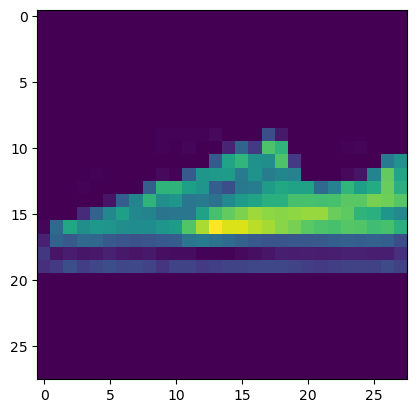

In [9]:
plt.figure()
plt.imshow(np.squeeze(train_images[210]))


In [10]:

train_labels[210]

7

In [11]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [12]:
train_images_norm = train_images / 255.0

In [13]:
test_images_norm = test_images / 255.0

In [14]:
conv1 = layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))

In [15]:
conv2 = layers.Conv2D(64, (3,3), activation='relu')

In [16]:
conv3 = layers.Conv2D(128, (3,3), activation='relu')

In [17]:
#Creating first Max. Pooling Layer
max_pool_1 = layers.MaxPooling2D((2,2))

#Creating second Max. Pooling Layer
max_pool_2 = layers.MaxPooling2D((2,2))

#Creating third Max. Pooling Layer
max_pool_3 = layers.MaxPooling2D((2,2))

In [18]:
flat_layer = layers.Flatten()

In [19]:
fc = layers.Dense(128, activation='relu')


In [20]:
output = layers.Dense(10, 'softmax')

In [21]:
model = models.Sequential()

model.add(conv1)
model.add(conv2)
model.add(conv3)
model.add(max_pool_1)
model.add(flat_layer)
model.add(fc)
model.add(output)

2023-07-15 00:45:06.823790: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 


In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 conv2d_2 (Conv2D)           (None, 22, 22, 128)       73856     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 128)      0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 15488)             0         
                                                                 
 dense (Dense)               (None, 128)               1982592   
                                                        

In [23]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
model.fit(train_images_norm, train_labels, epochs=20, batch_size=512, shuffle=True, validation_split=0.1)

Epoch 1/20
106/106 [==============================] - 44s 411ms/step - loss: 0.5811 - accuracy: 0.7963 - val_loss: 0.3732 - val_accuracy: 0.8687
Epoch 2/20
106/106 [==============================] - 43s 404ms/step - loss: 0.3202 - accuracy: 0.8865 - val_loss: 0.3097 - val_accuracy: 0.8880
Epoch 3/20
106/106 [==============================] - 43s 406ms/step - loss: 0.2625 - accuracy: 0.9049 - val_loss: 0.2644 - val_accuracy: 0.9050
Epoch 4/20
106/106 [==============================] - 43s 402ms/step - loss: 0.2293 - accuracy: 0.9162 - val_loss: 0.2499 - val_accuracy: 0.9080
Epoch 5/20
106/106 [==============================] - 42s 401ms/step - loss: 0.1978 - accuracy: 0.9275 - val_loss: 0.2233 - val_accuracy: 0.9213
Epoch 6/20
106/106 [==============================] - 43s 407ms/step - loss: 0.1751 - accuracy: 0.9363 - val_loss: 0.2265 - val_accuracy: 0.9193
Epoch 7/20
106/106 [==============================] - 43s 410ms/step - loss: 0.1529 - accuracy: 0.9442 - val_loss: 0.2195 - val_ac

In [25]:
# Early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [26]:
# Increase the number of epochs
model.fit(train_images_norm, train_labels, epochs=50, batch_size=512, shuffle=True, validation_split=0.1, callbacks=[early_stopping])


Epoch 1/50
106/106 [==============================] - 44s 416ms/step - loss: 0.0113 - accuracy: 0.9965 - val_loss: 0.4326 - val_accuracy: 0.9218
Epoch 2/50
106/106 [==============================] - 43s 405ms/step - loss: 0.0186 - accuracy: 0.9937 - val_loss: 0.4093 - val_accuracy: 0.9220
Epoch 3/50
106/106 [==============================] - 42s 400ms/step - loss: 0.0129 - accuracy: 0.9961 - val_loss: 0.4697 - val_accuracy: 0.9225
Epoch 4/50
106/106 [==============================] - 43s 402ms/step - loss: 0.0105 - accuracy: 0.9969 - val_loss: 0.4425 - val_accuracy: 0.9253
Epoch 5/50
106/106 [==============================] - 42s 401ms/step - loss: 0.0092 - accuracy: 0.9972 - val_loss: 0.4697 - val_accuracy: 0.9268
Epoch 6/50
106/106 [==============================] - 43s 405ms/step - loss: 0.0067 - accuracy: 0.9977 - val_loss: 0.4833 - val_accuracy: 0.9232
Epoch 7/50
106/106 [==============================] - 42s 401ms/step - loss: 0.0107 - accuracy: 0.9966 - val_loss: 0.5090 - val_ac

In [27]:
test_loss, test_accuracy = model.evaluate(test_images_norm, test_labels)

313/313 [==============================] - 10s 32ms/step - loss: 0.4465 - accuracy: 0.9172


In [28]:
# Print the updated test accuracy
print("Updated Test Accuracy:", test_accuracy)

Updated Test Accuracy: 0.9172000288963318


In [29]:
p = model.predict(test_images[:10])
print(p)

1/1 [==============================] - 0s 353ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [30]:
pred = np.argmax(p, axis=1)
print(pred)
print(test_labels[:10])


[9 2 1 1 6 1 4 6 5 7]
[9 2 1 1 6 1 4 6 5 7]


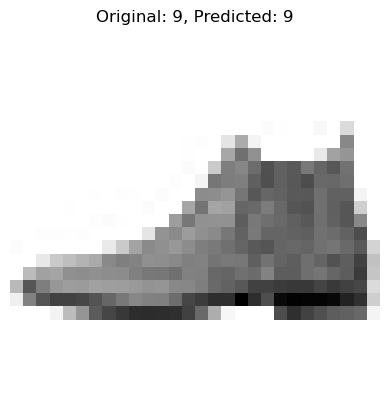

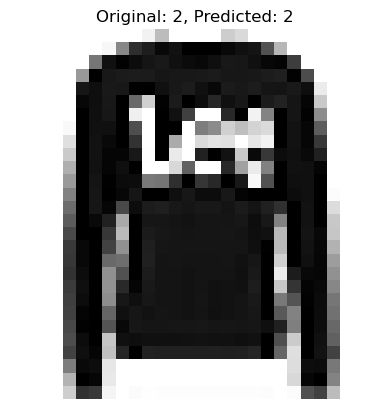

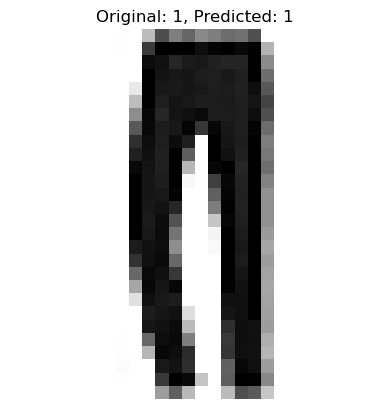

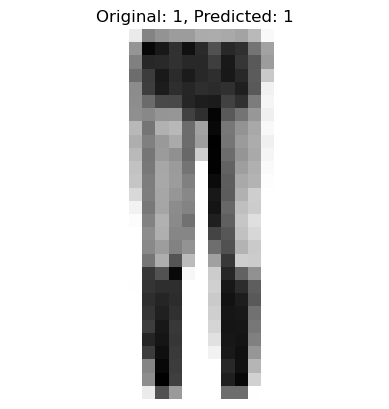

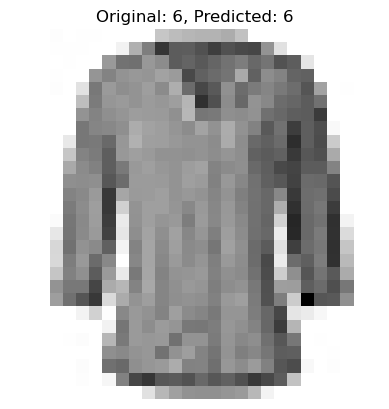

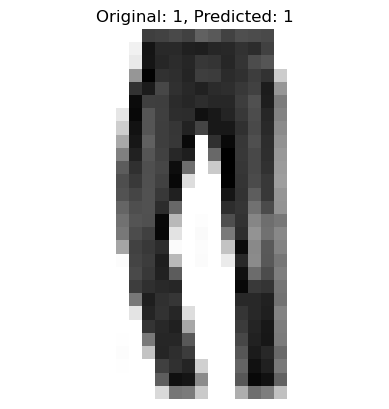

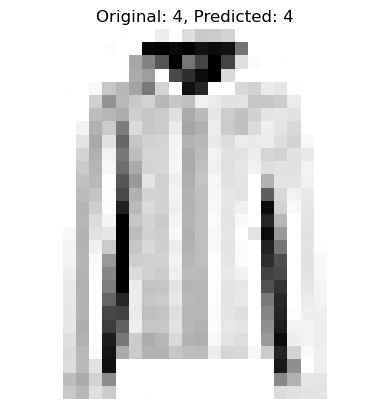

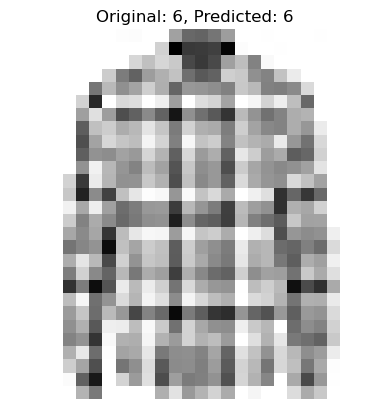

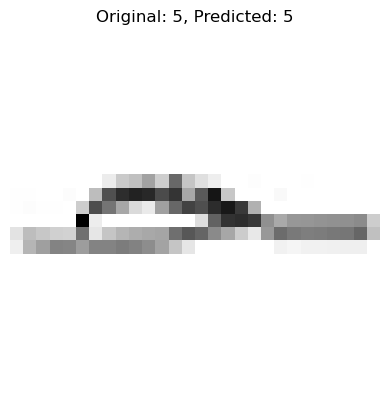

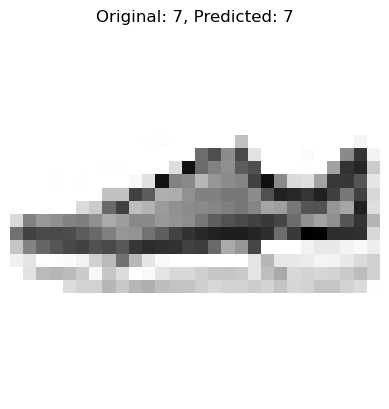

<Figure size 640x480 with 0 Axes>

In [31]:
# Visualizing the result
for i in range(10):
    plt.imshow(test_images[i], cmap="binary")
    plt.title('Original: {}, Predicted: {}'.format(test_labels[i], pred[i]))
    plt.axis("Off")
    plt.figure()

In [32]:
# Randomly select an image from the test set
index = np.random.randint(0, len(test_images_norm))
image = np.expand_dims(test_images_norm[index], axis=0)

In [33]:
import time

In [34]:
# Perform inference and measure the latency
start_time = time.time()
prediction = model.predict(image)
end_time = time.time()
inference_latency = end_time - start_time


1/1 [==============================] - 0s 61ms/step


In [35]:
# Get the predicted label
predicted_label = np.argmax(prediction)

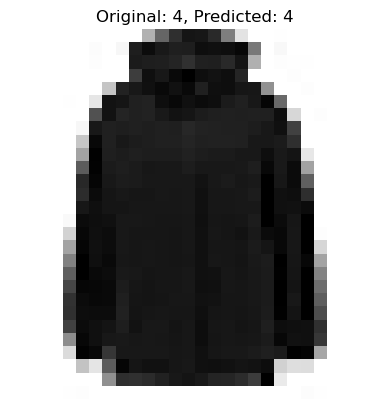

In [36]:
# Display the image and predicted label
plt.imshow(test_images[index], cmap="binary")
plt.title('Original: {}, Predicted: {}'.format(test_labels[index], predicted_label))
plt.axis("Off")
plt.show()

In [37]:
# Print the inference latency
print("Inference Latency: {:.4f} seconds".format(inference_latency))

Inference Latency: 0.1046 seconds


In [38]:
num_images = 1000
start_time = time.time()
for i in range(num_images):
    image = np.expand_dims(test_images_norm[i], axis=0)
    prediction = model.predict(image)

end_time = time.time()
inference_latency = (end_time - start_time) / num_images

1/1 [==============================] - 0s 29ms/step


In [39]:
# Print the baseline inference latency
print("Baseline Inference Latency: {:.4f} seconds per image".format(inference_latency))

Baseline Inference Latency: 0.0780 seconds per image


In [41]:
#Save the model
model.save("model_without_optimization.h5")